# Baseline vs eBPF: Split-Aware Detection Experiment

**Research questions addressed:**
> RQ1: Does eBPF monitoring improve detection accuracy vs Zeek-only features?  
> RQ5: Does eBPF reduce false positives by providing better context?

**Experiment design used in this notebook:**
- **Split 2**: model selection and threshold tuning for Isolation Forest, Random Forest, and HistGradientBoosting.
- **Split 4 `test_realistic`**: headline generalisation result.
- **Split 4 `test_balanced`**: per-attack fairness / class-balanced supporting view.
- **Split 1**: leakage diagnostic only.
- **Split 3**: resampled-training supporting diagnostic.
- **Split 5**: robustness metadata summary.

**Headline result:** HistGradientBoosting on **Split 4 `test_realistic`**. Everything else is supporting evidence.


In [1]:
import os, sys, json, time, warnings, subprocess
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score, accuracy_score,
    average_precision_score, confusion_matrix, RocCurveDisplay,
)
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT, f'Cannot find repo root from {HERE}'
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *

FEATURE_SETS = [
    ('baseline', MODEL_SELECTION_SPLITS_BASELINE, GENERALIZATION_SPLITS_BASELINE),
    ('ebpf',     MODEL_SELECTION_SPLITS_EBPF,     GENERALIZATION_SPLITS_EBPF),
]

SUPPORTING_SPLITS = {
    'split1_group_strat': {
        'role': 'leakage_diagnostic',
        'baseline_dir': SPLITS_1_BASELINE,
        'ebpf_dir': SPLITS_1_EBPF,
        'test_file': 'test.parquet',
    },
    'split2_balanced_quota': {
        'role': 'model_selection',
        'baseline_dir': SPLITS_2_BASELINE,
        'ebpf_dir': SPLITS_2_EBPF,
        'test_file': 'test.parquet',
    },
    'split3_train_resampled': {
        'role': 'resampled_training',
        'baseline_dir': SPLITS_3_BASELINE,
        'ebpf_dir': SPLITS_3_EBPF,
        'test_file': 'test.parquet',
    },
    'split4_balanced': {
        'role': 'balanced_fairness',
        'baseline_dir': SPLITS_4_BASELINE,
        'ebpf_dir': SPLITS_4_EBPF,
        'test_file': 'test_balanced.parquet',
    },
    'split4_realistic': {
        'role': 'headline_generalization',
        'baseline_dir': SPLITS_4_BASELINE,
        'ebpf_dir': SPLITS_4_EBPF,
        'test_file': 'test_realistic.parquet',
    },
}

print('[*] Repo root:', REPO_ROOT)
print('[*] Split 2 model-selection baseline:', MODEL_SELECTION_SPLITS_BASELINE)
print('[*] Split 2 model-selection ebpf    :', MODEL_SELECTION_SPLITS_EBPF)
print('[*] Split 4 headline baseline       :', GENERALIZATION_SPLITS_BASELINE)
print('[*] Split 4 headline ebpf           :', GENERALIZATION_SPLITS_EBPF)
print('[*] Supporting split keys           :', ', '.join(SUPPORTING_SPLITS.keys()))


[*] Repo root: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel
[*] Split 2 model-selection baseline: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split2_balanced_quota_baseline_seed42
[*] Split 2 model-selection ebpf    : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split2_balanced_quota_ebpf_seed42
[*] Split 4 headline baseline       : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_baseline_seed42
[*] Split 4 headline ebpf           : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split4_dual_eval_ebpf_seed42
[*] Supporting split keys           : split1_group_strat, split2_balanced_quota, split3_train_resampled, split4_balanced, split4_realistic


## Helper functions

In [ ]:
DROP_COLS = [
    'label_family', 'is_attack', 'day', 'label_raw', 'run_id',
    'ts', 'start_ts', 'end_ts', 't_end', 'orig_h', 'resp_h', 'src_ip', 'dst_ip', 'k',
    'label_time_offset_sec', 'label_halfday_shift_sec',
    'label_window_pre_slop_sec', 'label_window_post_slop_sec',
]

In [ ]:
def _numeric_cols(df: pd.DataFrame):
    X = df.drop(columns=DROP_COLS, errors='ignore')
    return [
        c for c in X.columns
        if pd.api.types.is_numeric_dtype(X[c]) and not X[c].isna().all()
    ]

In [ ]:
def make_imputer_on_train(train_df: pd.DataFrame, feat: list):
    from sklearn.impute import SimpleImputer
    X_raw = train_df.drop(columns=DROP_COLS, errors='ignore')[feat]
    imp = SimpleImputer(strategy='median')
    imp.fit(X_raw)
    return imp

In [ ]:
def prepare_with_imputer(df: pd.DataFrame, feat: list, imputer):
    X_raw = df.drop(columns=DROP_COLS, errors='ignore').copy()
    for c in feat:
        if c not in X_raw.columns:
            X_raw[c] = 0.0
    X_raw = X_raw[feat]
    X_arr = imputer.transform(X_raw)
    X_out = pd.DataFrame(X_arr, columns=feat, index=df.index)
    y = (df['is_attack'] == 1).astype(int).to_numpy()
    labels = df['label_family'].astype(str)
    return X_out, y, labels

In [ ]:
def load_split(splits_dir: Path, test_file: str = 'test.parquet'):
    tr = pd.read_parquet(splits_dir / 'train.parquet')
    va = pd.read_parquet(splits_dir / 'val.parquet')
    te = pd.read_parquet(splits_dir / test_file)
    return tr, va, te

In [ ]:
def binary_metrics(y_true, y_pred, y_prob=None) -> dict:
    m = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }
    if y_prob is not None:
        try:
            m['roc_auc'] = float(roc_auc_score(y_true, y_prob))
            m['pr_auc'] = float(average_precision_score(y_true, y_prob))
        except Exception:
            m['roc_auc'] = None
            m['pr_auc'] = None
    return m

In [ ]:
def tune_threshold(y_val, y_prob_val):
    from sklearn.metrics import roc_curve
    n_pos = int((y_val == 1).sum())
    if n_pos < 10:
        print(f'    [!] Only {n_pos} validation positives; using threshold=0.5')
        return 0.5
    _, _, thresholds = roc_curve(y_val, y_prob_val)
    f1s = [
        f1_score(y_val, (y_prob_val >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best = float(thresholds[int(np.argmax(f1s))])
    print(f'    Val-tuned threshold: {best:.5f}  (best val F1={max(f1s):.4f})')
    return best

In [ ]:
def print_overfit_table(name: str, tr: dict, va: dict, te: dict):
    print(f'\n[*] {name}')
    fmt = '    {split:6s}  acc={accuracy:.4f}  prec={precision:.4f}  rec={recall:.4f}  f1={f1:.4f}  roc_auc={auc}  pr_auc={pr}'
    for split, m in [('train', tr), ('val', va), ('test', te)]:
        print(fmt.format(
            split=split,
            auc=f'{m["roc_auc"]:.4f}' if m.get('roc_auc') is not None else 'N/A',
            pr=f'{m["pr_auc"]:.4f}' if m.get('pr_auc') is not None else 'N/A',
            **{k: v for k, v in m.items() if k not in ('roc_auc', 'pr_auc')},
        ))

In [ ]:
def plot_confusion(y_true, y_pred, title: str, out_path: Path):
    cm = confusion_matrix(y_true, y_pred)
    cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm_n, cmap='Blues')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f'{cm[i, j]}\n({cm_n[i, j]:.1%})',
                ha='center', va='center',
                color='white' if cm_n[i, j] > 0.5 else 'black',
                fontsize=9,
            )
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['BENIGN', 'ATTACK'])
    ax.set_yticklabels(['BENIGN', 'ATTACK'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

In [ ]:
def fit_hgb_pack(split_dir: Path):
    tr_df = pd.read_parquet(split_dir / 'train.parquet')
    va_df = pd.read_parquet(split_dir / 'val.parquet')
    feat = _numeric_cols(tr_df)
    imp = make_imputer_on_train(tr_df, feat)
    Xtr, ytr, ltr = prepare_with_imputer(tr_df, feat, imp)
    Xva, yva, lva = prepare_with_imputer(va_df, feat, imp)

    clf = HistGradientBoostingClassifier(**HGB_PARAMS)
    t0 = time.time()
    clf.fit(Xtr, ytr)
    fit_seconds = time.time() - t0

    tr_prob = clf.predict_proba(Xtr)[:, 1]
    va_prob = clf.predict_proba(Xva)[:, 1]
    best_thr = tune_threshold(yva, va_prob)

    train_metrics = binary_metrics(ytr, (tr_prob >= best_thr).astype(int), tr_prob)
    val_metrics = binary_metrics(yva, (va_prob >= best_thr).astype(int), va_prob)

    return {
        'model': clf,
        'imputer': imp,
        'features': feat,
        'threshold': best_thr,
        'fit_seconds': fit_seconds,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
    }

In [ ]:
def evaluate_hgb_pack(pack: dict, split_dir: Path, test_file: str):
    test_df = pd.read_parquet(split_dir / test_file)
    Xte, yte, lte = prepare_with_imputer(test_df, pack['features'], pack['imputer'])
    te_prob = pack['model'].predict_proba(Xte)[:, 1]
    te_pred = (te_prob >= pack['threshold']).astype(int)
    test_metrics = binary_metrics(yte, te_pred, te_prob)
    return {
        'test_metrics': test_metrics,
        'y_test': yte,
        'y_prob': te_prob,
        'y_pred': te_pred,
        'labels_test': lte,
        'n_rows': len(yte),
        'n_attacks': int(yte.sum()),
    }

In [ ]:
def run_hgb_split(fs_name: str, split_name: str, split_dir: Path, test_file: str, *, save_prefix: str | None = None):
    print(f'\n[*] HGB {fs_name} on {split_name} ({test_file})')
    pack = fit_hgb_pack(split_dir)
    ev = evaluate_hgb_pack(pack, split_dir, test_file)
    print_overfit_table(
        f'HGB {fs_name} [{split_name}]',
        pack['train_metrics'], pack['val_metrics'], ev['test_metrics']
    )

    out = {
        'model_path': None,
        'features': pack['features'],
        'threshold': pack['threshold'],
        'fit_seconds': pack['fit_seconds'],
        'train': pack['train_metrics'],
        'val': pack['val_metrics'],
        'test': ev['test_metrics'],
        'y_test': ev['y_test'].tolist(),
        'y_prob': ev['y_prob'].tolist(),
        'y_pred': ev['y_pred'].tolist(),
        'n_rows': ev['n_rows'],
        'n_attacks': ev['n_attacks'],
        'split_name': split_name,
        'test_file': test_file,
    }

    if save_prefix is not None:
        model_path = MODELS_DIR / f'{save_prefix}.joblib'
        joblib.dump(
            {
                'model': pack['model'],
                'imputer': pack['imputer'],
                'features': pack['features'],
                'threshold': pack['threshold'],
                'selected_model_name': 'hgb_balanced',
                'seed': RANDOM_SEED,
                'split_name': split_name,
                'test_file': test_file,
            },
            model_path,
        )
        plot_confusion(
            ev['y_test'], ev['y_pred'],
            f'HGB {fs_name}: {split_name} ({test_file})',
            REPORTS_DIR / f'{save_prefix}_confusion.png',
        )
        out['model_path'] = str(model_path)
    return out

In [ ]:
def bootstrap_auc(y_true, y_prob, n=200, seed=42):
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, yp))
    return np.array(aucs)

## Experiment A: Split 2 model selection

This section trains all three model families on **Split 2** only.

Interpretation:
- Use these results to compare baseline vs eBPF under stable, balanced class proportions.
- Split 2 test metrics are **NOT** the headline generalisation claim.
- The primary model is **HistGradientBoosting**.

In [3]:
iforest_results = {}
rf_results = {}
hgb_split2_results = {}

for fs_name, split2_dir, _split4_dir in FEATURE_SETS:
    print(f'\nSplit 2 model selection: {fs_name}')

    if_run = f'{fs_name}_iforest_split2_seed{RANDOM_SEED}'
    subprocess.run([
        'python3', 'ml/methods/unsupervised_iforest/train_iforest.py',
        '--splits_dir', str(split2_dir),
        '--run_name', if_run,
        '--out_models_dir', str(MODELS_DIR),
        '--out_reports_dir', str(REPORTS_DIR),
        '--n_estimators', str(IFOREST_PARAMS['n_estimators']),
        '--max_samples', str(IFOREST_PARAMS['max_samples']),
    ], check=True)
    iforest_results[fs_name] = json.loads((REPORTS_DIR / f'{if_run}_iforest_summary.json').read_text())

    rf_run = f'{fs_name}_rf_split2_seed{RANDOM_SEED}'
    subprocess.run([
        'python3', 'ml/methods/supervised_rf/train_random_forest.py',
        '--splits_dir', str(split2_dir),
        '--run_name', rf_run,
        '--out_models_dir', str(MODELS_DIR),
        '--out_reports_dir', str(REPORTS_DIR),
        '--n_estimators', str(RF_PARAMS['n_estimators']),
        '--max_depth', str(RF_PARAMS['max_depth']),
        '--n_jobs', str(RF_PARAMS.get('n_jobs', 1)),
        '--balance_classes',
    ], check=True)
    rf_results[fs_name] = json.loads((REPORTS_DIR / f'{rf_run}_rf_summary.json').read_text())

    hgb_save = f'{fs_name}_hgb_split2_seed{RANDOM_SEED}'
    hgb_split2_results[fs_name] = run_hgb_split(
        fs_name,
        'split2_balanced_quota',
        split2_dir,
        'test.parquet',
        save_prefix=hgb_save,
    )

model_selection_rows = []
for model_name, results_dict in [
    ('IsolationForest', iforest_results),
    ('RandomForest', rf_results),
    ('HGB', hgb_split2_results),
]:
    for fs_name in ['baseline', 'ebpf']:
        if fs_name not in results_dict:
            continue
        r = results_dict[fs_name]
        te = r.get('test', {})
        va = r.get('validation', r.get('val', {}))
        model_selection_rows.append({
            'split': 'split2_balanced_quota',
            'role': 'model_selection',
            'model': model_name,
            'feature_set': fs_name,
            'val_f1': va.get('f1'),
            'val_roc_auc': va.get('roc_auc'),
            'val_pr_auc': va.get('pr_auc'),
            'test_f1': te.get('f1'),
            'test_roc_auc': te.get('roc_auc'),
            'test_pr_auc': te.get('pr_auc'),
        })

model_selection_df = pd.DataFrame(model_selection_rows).sort_values(
    ['model', 'feature_set']
).reset_index(drop=True)
print(model_selection_df.to_string(index=False, float_format='{:.4f}'.format))

model_selection_csv = REPORTS_DIR / f'model_selection_split2_seed{RANDOM_SEED}.csv'
model_selection_df.to_csv(model_selection_csv, index=False)
print(f'\n[+] Saved model-selection summary: {model_selection_csv}')

for fs_name in ['baseline', 'ebpf']:
    src_model_path = Path(hgb_split2_results[fs_name]['model_path'])
    hgb_pack = joblib.load(src_model_path)
    best_pack = {
        'model': hgb_pack['model'],
        'imputer': hgb_pack.get('imputer'),
        'features': hgb_pack['features'],
        'threshold': hgb_pack['threshold'],
        'selected_model_name': 'hgb_balanced',
        'source_model_path': str(src_model_path),
        'seed': RANDOM_SEED,
        'selected_on_split': 'split2_balanced_quota',
    }
    out_path = MODELS_DIR / f'{fs_name}_best_model_seed{RANDOM_SEED}.joblib'
    joblib.dump(best_pack, out_path)
    print(f'[+] Saved canonical best model: {out_path}')



Split 2 model selection: baseline
[*] Isolation Forest: baseline_iforest_split2_seed42
  splits_dir      : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/datasets/split2_balanced_quota_baseline_seed42
  out_models_dir  : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/models
  out_reports_dir : /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports
  parameters:
    n_estimators       100
    max_samples        512
    contamination      auto
    random_state       1337
[*] Split sizes
  train: rows=   33,692  benign=   16,842 ( 50.0%)  attack=   16,850 ( 50.0%)
  val  : rows=    7,220  benign=    3,601 ( 49.9%)  attack=    3,619 ( 50.1%)
  test : rows=    7,220  benign=    3,623 ( 50.2%)  attack=    3,597 ( 49.8%)
[*] Preprocessing: numeric-only ColumnTransformer with median imputation + StandardScaler, fit on benign train rows only
[*] Feature space: 10 numeric features
  preview         : duration, orig_p, resp_p, orig_bytes, resp_bytes, orig_pkts

## Experiment B: Headline evaluation on Split 4

This is the main result section.

For each feature set:
- fit HGB on **Split 4 `train.parquet`**,
- tune threshold on **Split 4 `val.parquet`**,
- report the headline result on **`test_realistic.parquet`**,
- keep **`test_balanced.parquet`** as a supporting fairness view.


In [4]:
headline_results = {}
split4_balanced_results = {}

for fs_name, _split2_dir, split4_dir in FEATURE_SETS:
    print(f'\nSplit 4 headline evaluation: {fs_name}')
    pack = fit_hgb_pack(split4_dir)

    realistic = evaluate_hgb_pack(pack, split4_dir, 'test_realistic.parquet')
    balanced = evaluate_hgb_pack(pack, split4_dir, 'test_balanced.parquet')

    print_overfit_table(
        f'HGB {fs_name} [split4_realistic]',
        pack['train_metrics'], pack['val_metrics'], realistic['test_metrics']
    )
    print(f"    Balanced support set: rows={balanced['n_rows']:,}  attacks={balanced['n_attacks']:,}")
    print(f"    Realistic headline  : rows={realistic['n_rows']:,}  attacks={realistic['n_attacks']:,}")

    model_path = MODELS_DIR / f'{fs_name}_hgb_split4_seed{RANDOM_SEED}.joblib'
    joblib.dump(
        {
            'model': pack['model'],
            'imputer': pack['imputer'],
            'features': pack['features'],
            'threshold': pack['threshold'],
            'selected_model_name': 'hgb_balanced',
            'seed': RANDOM_SEED,
            'split_name': 'split4_dual_eval',
        },
        model_path,
    )

    plot_confusion(
        realistic['y_test'], realistic['y_pred'],
        f'HGB {fs_name}: Split 4 realistic',
        REPORTS_DIR / f'{fs_name}_hgb_split4_realistic_seed{RANDOM_SEED}_confusion.png',
    )
    plot_confusion(
        balanced['y_test'], balanced['y_pred'],
        f'HGB {fs_name}: Split 4 balanced',
        REPORTS_DIR / f'{fs_name}_hgb_split4_balanced_seed{RANDOM_SEED}_confusion.png',
    )

    headline_results[fs_name] = {
        'model_path': str(model_path),
        'features': pack['features'],
        'threshold': pack['threshold'],
        'train': pack['train_metrics'],
        'val': pack['val_metrics'],
        'test': realistic['test_metrics'],
        'y_test': realistic['y_test'].tolist(),
        'y_prob': realistic['y_prob'].tolist(),
        'y_pred': realistic['y_pred'].tolist(),
        'test_file': 'test_realistic.parquet',
        'split_name': 'split4_realistic',
        'n_rows': realistic['n_rows'],
        'n_attacks': realistic['n_attacks'],
    }
    split4_balanced_results[fs_name] = {
        'test': balanced['test_metrics'],
        'y_test': balanced['y_test'].tolist(),
        'y_prob': balanced['y_prob'].tolist(),
        'y_pred': balanced['y_pred'].tolist(),
        'test_file': 'test_balanced.parquet',
        'split_name': 'split4_balanced',
        'n_rows': balanced['n_rows'],
        'n_attacks': balanced['n_attacks'],
    }

headline_rows = []
for fs_name in ['baseline', 'ebpf']:
    te = headline_results[fs_name]['test']
    headline_rows.append({
        'headline_split': 'split4_realistic',
        'model': 'HGB',
        'feature_set': fs_name,
        'rows': headline_results[fs_name]['n_rows'],
        'attacks': headline_results[fs_name]['n_attacks'],
        'accuracy': te.get('accuracy'),
        'precision': te.get('precision'),
        'recall': te.get('recall'),
        'f1': te.get('f1'),
        'roc_auc': te.get('roc_auc'),
        'pr_auc': te.get('pr_auc'),
    })

headline_df = pd.DataFrame(headline_rows)
print('\nHeadline result: Split 4 realistic')
print(headline_df.to_string(index=False, float_format='{:.4f}'.format))

headline_csv = REPORTS_DIR / f'headline_split4_realistic_seed{RANDOM_SEED}.csv'
headline_df.to_csv(headline_csv, index=False)
print(f'\n[+] Saved headline summary: {headline_csv}')



Split 4 headline evaluation: baseline
    Val-tuned threshold: 0.00046  (best val F1=0.2153)

[*] HGB baseline [split4_realistic]
    train   acc=0.9683  prec=0.8380  rec=1.0000  f1=0.9118  roc_auc=1.0000  pr_auc=0.9998
    val     acc=0.9670  prec=0.1225  rec=0.8858  f1=0.2153  roc_auc=0.9721  pr_auc=0.0941
    test    acc=0.6800  prec=0.8344  rec=0.3681  f1=0.5108  roc_auc=0.9202  pr_auc=0.8575
    Balanced support set: rows=16  attacks=8
    Realistic headline  : rows=546,207  attacks=247,953

Split 4 headline evaluation: ebpf
    Val-tuned threshold: 0.00045  (best val F1=0.2005)

[*] HGB ebpf [split4_realistic]
    train   acc=0.9808  prec=0.8949  rec=1.0000  f1=0.9446  roc_auc=1.0000  pr_auc=0.9999
    val     acc=0.9763  prec=0.1212  rec=0.5810  f1=0.2005  roc_auc=0.9704  pr_auc=0.0904
    test    acc=0.6851  prec=0.8572  rec=0.3675  f1=0.5144  roc_auc=0.7115  pr_auc=0.7155
    Balanced support set: rows=16  attacks=8
    Realistic headline  : rows=546,207  attacks=247,953

Hea

## Experiment C: Supporting diagnostics across Splits 1, 2, 3, and 4

This section keeps the headline result separate while still showing how the recommended HGB model behaves across the other split designs.

Interpretation:
- **Split 1**: leakage stress test only.
- **Split 2**: model-selection view only.
- **Split 3**: does resampled training help rare classes?
- **Split 4 balanced**: class-balanced support view.
- **Split 4 realistic**: headline result, repeated here for one-table comparability.


In [5]:
supporting_rows = []
supporting_results = {}

for split_name, meta in SUPPORTING_SPLITS.items():
    supporting_results[split_name] = {}
    for fs_name in ['baseline', 'ebpf']:
        split_dir = meta['baseline_dir'] if fs_name == 'baseline' else meta['ebpf_dir']
        if not Path(split_dir).exists():
            print(f'[!] Missing split directory for {split_name} / {fs_name}: {split_dir}')
            continue
        res = run_hgb_split(
            fs_name,
            split_name,
            Path(split_dir),
            meta['test_file'],
            save_prefix=None,
        )
        supporting_results[split_name][fs_name] = res
        te = res['test']
        supporting_rows.append({
            'split': split_name,
            'role': meta['role'],
            'model': 'HGB',
            'feature_set': fs_name,
            'rows': res['n_rows'],
            'attacks': res['n_attacks'],
            'test_f1': te.get('f1'),
            'test_roc_auc': te.get('roc_auc'),
            'test_pr_auc': te.get('pr_auc'),
            'test_precision': te.get('precision'),
            'test_recall': te.get('recall'),
        })

supporting_df = pd.DataFrame(supporting_rows)
role_order = {
    'model_selection': 0,
    'headline_generalization': 1,
    'balanced_fairness': 2,
    'resampled_training': 3,
    'leakage_diagnostic': 4,
}
if not supporting_df.empty:
    supporting_df = supporting_df.assign(_ord=supporting_df['role'].map(role_order)).sort_values(
        ['_ord', 'split', 'feature_set']
    ).drop(columns=['_ord']).reset_index(drop=True)
    print(supporting_df.to_string(index=False, float_format='{:.4f}'.format))
    supporting_csv = REPORTS_DIR / f'supporting_hgb_all_splits_seed{RANDOM_SEED}.csv'
    supporting_df.to_csv(supporting_csv, index=False)
    print(f'\n[+] Saved supporting split summary: {supporting_csv}')
else:
    print('[!] No supporting split results were generated.')



[*] HGB baseline on split1_group_strat (test.parquet)
    Val-tuned threshold: 0.85483  (best val F1=0.0634)

[*] HGB baseline [split1_group_strat]
    train   acc=0.9895  prec=0.9867  rec=0.9753  f1=0.9809  roc_auc=0.9991  pr_auc=0.9906
    val     acc=0.9778  prec=0.0338  rec=0.5180  f1=0.0634  roc_auc=0.9390  pr_auc=0.0192
    test    acc=0.9807  prec=0.0399  rec=0.5530  f1=0.0745  roc_auc=0.9856  pr_auc=0.0579

[*] HGB ebpf on split1_group_strat (test.parquet)
    Val-tuned threshold: 0.98190  (best val F1=0.5316)

[*] HGB ebpf [split1_group_strat]
    train   acc=0.9793  prec=0.9987  rec=0.9263  f1=0.9612  roc_auc=0.9998  pr_auc=0.9994
    val     acc=0.9990  prec=0.8079  rec=0.3961  f1=0.5316  roc_auc=0.9828  pr_auc=0.4461
    test    acc=0.9987  prec=0.5882  rec=0.3152  f1=0.4104  roc_auc=0.9991  pr_auc=0.5584

[*] HGB baseline on split2_balanced_quota (test.parquet)
    Val-tuned threshold: 0.32544  (best val F1=0.9842)

[*] HGB baseline [split2_balanced_quota]
    train   acc

## ROC curve comparison for the headline split


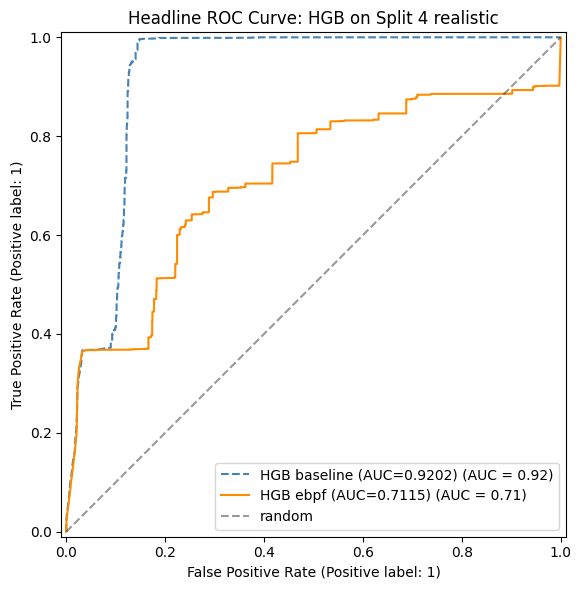

[+] Saved ROC plot: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/roc_hgb_split4_realistic_seed42.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

for fs_name, colour, ls in [('baseline', 'steelblue', '--'), ('ebpf', 'darkorange', '-')]:
    if fs_name not in headline_results:
        continue
    r = headline_results[fs_name]
    yt = np.array(r['y_test'])
    yp = np.array(r['y_prob'])
    auc = r['test']['roc_auc']
    RocCurveDisplay.from_predictions(
        yt, yp, ax=ax,
        name=f'HGB {fs_name} (AUC={auc:.4f})',
        color=colour, linestyle=ls,
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='random')
ax.set_title('Headline ROC Curve: HGB on Split 4 realistic')
ax.legend()
plt.tight_layout()
out_png = REPORTS_DIR / f'roc_hgb_split4_realistic_seed{RANDOM_SEED}.png'
plt.savefig(out_png, dpi=150)
plt.show()
print(f'[+] Saved ROC plot: {out_png}')


## Split 5 robustness metadata summary

Split 5 is a robustness split rather than a single headline test set. This cell summarises the fold metadata.


In [7]:
robustness_rows = []
for fs_name, split5_dir in [('baseline', SPLITS_5_BASELINE), ('ebpf', SPLITS_5_EBPF)]:
    meta_path = Path(split5_dir) / 'folds_meta.json'
    if not meta_path.exists():
        print(f'[!] Split 5 metadata not found for {fs_name}: {meta_path}')
        continue
    meta = json.loads(meta_path.read_text())
    folds = meta.get('folds', [])
    if not folds:
        print(f'[!] Split 5 metadata is empty for {fs_name}: {meta_path}')
        continue
    train_rows = [f['train_rows'] for f in folds]
    test_rows = [f['test_rows'] for f in folds]
    test_attacks = [f['test_attacks'] for f in folds]
    unseen_count = sum(1 for f in folds if f.get('unseen_in_train'))
    robustness_rows.append({
        'feature_set': fs_name,
        'n_folds': len(folds),
        'mean_train_rows': float(np.mean(train_rows)),
        'mean_test_rows': float(np.mean(test_rows)),
        'mean_test_attacks': float(np.mean(test_attacks)),
        'folds_with_unseen_families': int(unseen_count),
    })

robustness_df = pd.DataFrame(robustness_rows)
if not robustness_df.empty:
    print(robustness_df.to_string(index=False, float_format='{:.2f}'.format))
    robustness_csv = REPORTS_DIR / f'robustness_split5_metadata_seed{RANDOM_SEED}.csv'
    robustness_df.to_csv(robustness_csv, index=False)
    print(f'\n[+] Saved Split 5 metadata summary: {robustness_csv}')
else:
    print('[!] No Split 5 metadata available to summarize.')


feature_set  n_folds  mean_train_rows  mean_test_rows  mean_test_attacks  folds_with_unseen_families
   baseline       15       1692188.80       423047.20           89471.60                           9
       ebpf       15       1692188.80       423047.20           89471.60                           9

[+] Saved Split 5 metadata summary: /mnt/c/Users/merin/Documents/GitHub/ebpf-net-sentinel/data/reports/robustness_split5_metadata_seed42.csv
